Successfully loaded data for 27 batteries.
Deriving 'cycle_life' by counting cycles in the 'cycle_data' column...

--- Shapiro-Wilk Test for Normality on 'cycle_life' ---
Test Statistic: 0.2070, P-value: 0.0000
Conclusion: The data does not appear to be normally distributed (reject H0).

--- Generating Q-Q Plot ---


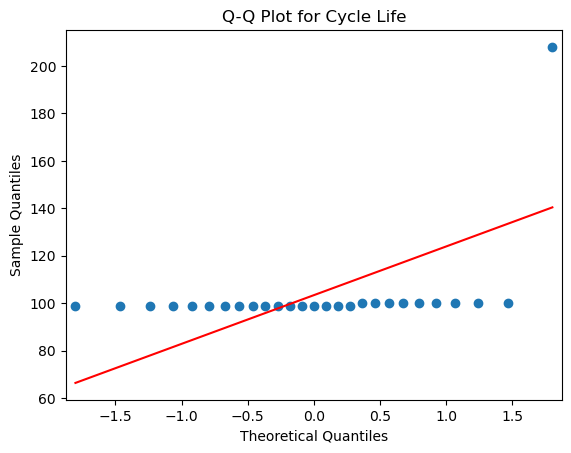

In [30]:
import pandas as pd
import requests
import zipfile
import io
import statsmodels.api as sm
from scipy.stats import shapiro
import matplotlib.pyplot as plt

# URL for the direct download of the zip file from Zenodo
url = 'https://zenodo.org/records/15531867/files/CALB.zip'

print(f"Downloading data from {url}...")

try:
    # 1. Download and process the data
    response = requests.get(url)
    response.raise_for_status()
    zip_content = io.BytesIO(response.content)

    all_battery_data = []
    with zipfile.ZipFile(zip_content, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        for file_name in file_list:
            if file_name.endswith('.pkl'):
                with zip_ref.open(file_name) as pkl_file:
                    dict_from_file = pd.read_pickle(pkl_file)
                    df_from_file = pd.DataFrame([dict_from_file])
                    all_battery_data.append(df_from_file)

    if not all_battery_data:
        print("Error: No data was loaded.")
    else:
        combined_df = pd.concat(all_battery_data, ignore_index=True)
        print(f"Successfully loaded data for {len(combined_df)} batteries.")

        # --- KEY STEP: Create the 'cycle_life' column ---
        if 'cycle_data' in combined_df.columns:
            print("Deriving 'cycle_life' by counting cycles in the 'cycle_data' column...")
            # The length of the 'cycle_data' list is the cycle life
            combined_df['cycle_life'] = combined_df['cycle_data'].apply(len)
        else:
            raise KeyError("The necessary 'cycle_data' column was not found to calculate cycle life.")

        # --- Univariate Test for Normality on the new 'cycle_life' column ---
        combined_df.dropna(subset=['cycle_life'], inplace=True)
        cycle_life_data = combined_df['cycle_life']
        
        # a) Shapiro-Wilk Statistical Test
        print("\n--- Shapiro-Wilk Test for Normality on 'cycle_life' ---")
        stat, p_value = shapiro(cycle_life_data)
        print(f"Test Statistic: {stat:.4f}, P-value: {p_value:.4f}")

        alpha = 0.05
        if p_value > alpha:
            print("Conclusion: The data appears to be normally distributed (fail to reject H0).")
        else:
            print("Conclusion: The data does not appear to be normally distributed (reject H0).")

        # b) Q-Q Plot Visual Test
        print("\n--- Generating Q-Q Plot ---")
        fig = sm.qqplot(cycle_life_data, line='s')
        plt.title('Q-Q Plot for Cycle Life')
        plt.xlabel('Theoretical Quantiles')
        plt.ylabel('Sample Quantiles')
        plt.show()

except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [15]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_ind

# -----------------------------------------------------------------------------
# Step 0: Data Ingestion
# -----------------------------------------------------------------------------
# Direct link to the raw CSV file on GitHub
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'

print(f"Downloading data from {url}...")
try:
    df = pd.read_csv(url)
    print("Data loaded successfully.")
    print("First 5 rows of the dataset:")
    print(df.head())
    print(f"\nDataset shape: {df.shape}")

except Exception as e:
    print(f"An error occurred during data loading: {e}")
    exit() # Exit if data loading fails

# Clean the data: drop rows with missing 'sex' or 'body_mass_g'
df.dropna(subset=['sex', 'body_mass_g'], inplace=True)
# The dataset contains a 'sex' value of '.', which should be removed.
df = df[df['sex'] != '.']


# Separate data by sex
male_mass = df[df['sex'] == 'male']['body_mass_g']
female_mass = df[df['sex'] == 'female']['body_mass_g']

print(f"\nMale penguins count: {len(male_mass)}")
print(f"Female penguins count: {len(female_mass)}")


# -----------------------------------------------------------------------------
# Univariate Test for Normality Application
# -----------------------------------------------------------------------------
print("\n--- Step 1: Univariate Test for Normality (Shapiro-Wilk) ---")
alpha = 0.05

# Normality for Male Body Mass
print("\n-- Normality Test for Male Body Mass --")
stat_male, p_male = shapiro(male_mass)
print(f"Shapiro-Wilk Test Statistic (Male): {stat_male:.4f}, P-value: {p_male:.4f}")
if p_male > alpha:
    print("Conclusion (Male): Data appears normally distributed (Fail to reject H0).")
else:
    print("Conclusion (Male): Data does NOT appear normally distributed (Reject H0).")

# Normality for Female Body Mass
print("\n-- Normality Test for Female Body Mass --")
stat_female, p_female = shapiro(female_mass)
print(f"Shapiro-Wilk Test Statistic (Female): {stat_female:.4f}, P-value: {p_female:.4f}")
if p_female > alpha:
    print("Conclusion (Female): Data appears normally distributed (Fail to reject H0).")
else:
    print("Conclusion (Female): Data does NOT appear normally distributed (Reject H0).")


Data loaded successfully.
First 5 rows of the dataset:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

Dataset shape: (344, 8)

Male penguins count: 168
Female penguins count: 165

--- Step 1: Univariate Test for Normality (Shapiro-Wilk) ---

-- Normality Test for Male Body Mass --
Shapiro-Wilk Test Statistic (Male): 0.9250, P-value: 0.0000
Conclusion (Male): Data does NOT appear normally distributed (Reject H0).

In [ ]:
# -----------------------------------------------------------------------------
# Parametric Test Application (Independent Samples t-test)
# -----------------------------------------------------------------------------
print("\n--- Parametric Test Application (Independent Samples t-test) ---")

# Perform independent samples t-test
ttest_stat, ttest_p_value = ttest_ind(male_mass, female_mass)

print(f"\nIndependent Samples t-test Results:")
print(f"  t-statistic: {ttest_stat:.4f}")
print(f"  P-value: {ttest_p_value}")

# Interpretation of the t-test p-value
if ttest_p_value < alpha:
    print(f"\nConclusion: Since the p-value is less than alpha ({alpha}), we reject the Null Hypothesis (H0).")
    print("There is a statistically significant difference in mean body mass between male and female penguins.")
else:
    print(f"\nConclusion: Since the p-value is greater than or equal to alpha ({alpha}), we fail to reject the Null Hypothesis (H0).")
    print("There is no statistically significant difference in mean body mass between male and female penguins.")

# Also useful to see the means for context
print(f"\nMean Body Mass for Male Penguins: {male_mass.mean():.2f} g")
print(f"Mean Body Mass for Female Penguins: {female_mass.mean():.2f} g")


--- Step 3: Parametric Test Application (Independent Samples t-test) ---

Independent Samples t-test Results:
  t-statistic: 8.5417
  P-value: 4.897246751596224e-16

Conclusion: Since the p-value is less than alpha (0.05), we reject the Null Hypothesis (H0).
There is a statistically significant difference in mean body mass between male and female penguins.

Mean Body Mass for Male Penguins: 4545.68 g
Mean Body Mass for Female Penguins: 3862.27 g


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
url = "https://raw.githubusercontent.com/ilyankou/passport-index-dataset/master/passport-index-matrix.csv"
df = pd.read_csv(url)
df.set_index(df.columns[0], inplace=True)
destinations = df.columns
# ---- Pre-process / calculate scores ----
# (A) visa access score
good_statuses = ['visa free', 'visa on arrival', 'eta']
# not the cleanest way, but I’ll convert to numeric where possible, then check text
numeric_access = df[destinations].apply(pd.to_numeric, errors="coerce").fillna(0) > 0
text_access = df[destinations].isin(good_statuses)
# counting how many destinations are accessible at all
df["visa_access_score"] = (numeric_access | text_access).sum(axis=1)
# (B) break it down: visa free vs on-arrival
num_vf = df[destinations].apply(pd.to_numeric, errors="coerce").fillna(0) > 0
txt_vf = df[destinations] == "visa free"
df["visa_free_score"] = (num_vf | txt_vf).sum(axis=1)
df["visa_on_arrival_score"] = (df[destinations] == "visa on arrival").sum(axis=1)
# ---- Region data (for 2-sample t-test) ----
# not comprehensive obviously... just hardcoding a few
continents = {
    "Europe": ["Germany", "Spain", "Finland", "United Kingdom"],
    "Africa": ["Nigeria", "South Africa", "Egypt", "Kenya"]
}
# map countries -> regions
region_lookup = {c: cont for cont, countries in continents.items() for c in countries}
df["region"] = df.index.map(region_lookup)
# ---- Perform t-tests ----
# One-sample test (is average access score different from 120?)
one_samp_test = stats.ttest_1samp(df["visa_access_score"], 120)
print("One-Sample T-Test (Overall Visa Access Score vs 120):")
print(f"stat={one_samp_test.statistic:.4f}, p={one_samp_test.pvalue:.4f}\n")
# Paired test: visa-free vs on-arrival
paired_test = stats.ttest_rel(df["visa_free_score"], df["visa_on_arrival_score"])
print("Paired T-Test (Visa-Free vs Visa-on-Arrival):")
print(f"stat={paired_test.statistic:.4f}, p={paired_test.pvalue:.4f}\n")
# Independent test: Europe vs Africa
eu_vals = df[df["region"] == "Europe"]["visa_access_score"]
af_vals = df[df["region"] == "Africa"]["visa_access_score"]


if eu_vals.size > 0 and af_vals.size > 0:
    indep_test = stats.ttest_ind(eu_vals, af_vals, equal_var=False)  # Welch’s
    print("Independent T-Test (Europe vs Africa):")
    print(f"stat={indep_test.statistic:.4f}, p={indep_test.pvalue:.4f}")
else:
    print("Independent test skipped - missing enough countries in Europe/Africa list.")


One-Sample T-Test (Overall Visa Access Score vs 120):
stat=-6.5110, p=0.0000

Paired T-Test (Visa-Free vs Visa-on-Arrival):
stat=12.8398, p=0.0000

Independent T-Test (Europe vs Africa):
stat=8.1223, p=0.0038
